In [125]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy import integrate

from committor.notebook_api import (
    find_committor,
    make_basis,
    make_gaussian_product_states,
    create_mixture_tt_density,
)

plt.rcParams.update({
    "figure.figsize": (7.5, 5.5),
    "axes.grid": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})


# double-well

## checking 1D things

In [28]:
d = 4

beta = 10.0
rho = 400.0

In [29]:
# equilibrium density factor (product structure required)
weight_fns = [lambda x: np.exp(-beta * (x**2 - 1.0)**2)] * d

# metastable states (around (-1,...,-1) and (+1,...,+1))
wA_fns, wB_fns = make_gaussian_product_states(
    a_center=[-1.0]*d,
    b_center=[+1.0]*d,
    sigma=0.15,
)

# solve in 4D using TT
result_4d = find_committor(
    basis_kind="legendre",
    ns=[40]*d,
    intervals=[(-2.0, 2.0)]*d,
    weight_fns=weight_fns,
    wA_fns=wA_fns,
    wB_fns=wB_fns,
    rho=rho,
    method="tt",
)

In [30]:
result_1d = find_committor(
    V=lambda x: (x**2 - 1.0)**2,
    beta=beta,
    a=-2.0,
    b=2.0,
    nbasis=80,   # higher resolution for reference
    rho=rho,
)

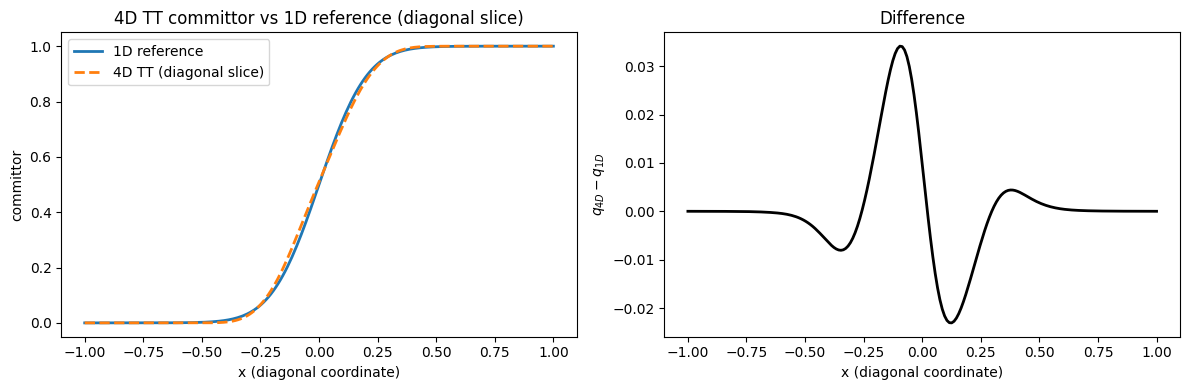

In [31]:
xs = np.linspace(-1, 1, 200)

# 4D evaluation: points of form (x,x,x,x)
pts = np.array([[x]*d for x in xs])
q_4d = result_4d.q(pts)

# 1D reference
q_1d = result_1d.q(xs)

# absolute difference
diff = q_4d - q_1d

# --- plotting with axes ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Top: committors
axes[0].plot(xs, q_1d, label="1D reference", linewidth=2)
axes[0].plot(xs, q_4d, "--", label="4D TT (diagonal slice)", linewidth=2)
axes[0].set_xlabel("x (diagonal coordinate)")
axes[0].set_ylabel("committor")
axes[0].set_title("4D TT committor vs 1D reference (diagonal slice)")
axes[0].legend()

# Bottom: absolute difference
axes[1].plot(xs, diff, color="black", linewidth=2)
axes[1].set_xlabel("x (diagonal coordinate)")
axes[1].set_ylabel(r"$q_{4D} - q_{1D}$")
axes[1].set_title("Difference")

plt.tight_layout()
#plt.savefig('/Users/matias/Downloads/committor_project/figs/dw_test.png', dpi=300)
plt.show()

In [315]:
dims = np.arange(1,40,2)
times = []

beta = 10.0
rho = 400.0

for dim in dims:
    weight_fns = [lambda x: np.exp(-beta * (x**2 - 1.0)**2)] * dim
  
    wA_fns, wB_fns = make_gaussian_product_states(
        a_center=[-1.0]*dim,
        b_center=[+1.0]*dim,
        sigma=0.15,
    )

    start = time.time()
    find_committor(
        basis_kind="legendre",
        ns=[10]*dim,
        intervals=[(-2.0, 2.0)]*dim,
        weight_fns=weight_fns,
        wA_fns=wA_fns,
        wB_fns=wB_fns,
        rho=rho,
        method="tt",
    )
    times.append(time.time()-start)

Text(0, 0.5, 'Time (s)')

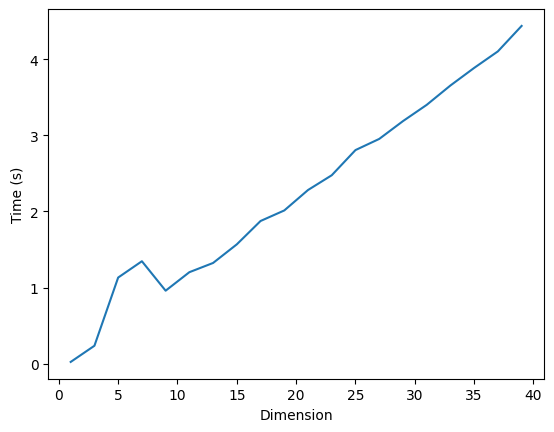

In [316]:
plt.plot(dims,times)
plt.xlabel('Dimension')
plt.ylabel('Time (s)')
#plt.savefig('/Users/matias/Downloads/committor_project/figs/dw_timing.png', dpi=300)

## a slightly more interesting double-well

In [303]:
d      = 8      # ← change freely; everything below adapts
beta_x = 1.0   # barrier height for the double-well (dim 0)
beta_y = 2.0   # Gaussian confinement for dims 1 … d-1
rho    = 400.0

In [304]:
# ── solver inputs ─────────────────────────────────────────────────────────────
weight_fns = (
    [lambda x: np.exp(-beta_x * (x**2 - 1.0)**2)] +  # double-well in dim 0
    [lambda x: np.exp(-beta_y * x**2)] * (d - 1)      # Gaussian in dims 1…d-1
)

wA_fns, wB_fns = make_gaussian_product_states(
    a_center=[-1.0] + [0.0] * (d - 1),
    b_center=[+1.0] + [0.0] * (d - 1),
    sigma=0.8,
)

result = find_committor(
    basis_kind="legendre",
    ns=[20] * d,
    intervals=[(-2.0, 2.0)] * d,
    weight_fns=weight_fns,
    wA_fns=wA_fns,
    wB_fns=wB_fns,
    rho=rho,
    method="tt",
)

In [305]:
# ── analytical committor (always just a 1D formula in x₀, for any d) ─────────
def committor_1d(x_vals):
    """
    True q depends only on x₀.  The y-directions cancel from the generator
    because U is separable and A, B place no constraint on them.
    """
    integrand = lambda s: np.exp(beta_x * (s**2 - 1.0)**2)
    Z, _ = integrate.quad(integrand, -1.0, 1.0)
    q = np.empty(len(x_vals), dtype=float)
    for i, x in enumerate(x_vals):
        if   x <= -1.0: q[i] = 0.0
        elif x >=  1.0: q[i] = 1.0
        else:
            num, _ = integrate.quad(integrand, -1.0, x)
            q[i] = num / Z
    return q

# ── evaluation helpers ────────────────────────────────────────────────────────
Ng = 200
xv = np.linspace(-2.0, 2.0, Ng)

def eval_algo_on_slice(fix_y=0.0):
    """
    Evaluate the TT committor on the (x₀, x₁) plane with dims 2…d-1 = fix_y.
    Returns an (Ng, Ng) array.
    """
    yv  = np.linspace(-2.0, 2.0, Ng)
    X, Y = np.meshgrid(xv, yv)                # (Ng, Ng) each
    pts = np.full((Ng * Ng, d), fix_y)
    pts[:, 0] = X.ravel()
    pts[:, 1] = Y.ravel()

    # NOTE: adjust unpacking to match result's actual evaluation API,
    #       e.g. result.evaluate(pts) or result.evaluate(*pts.T)
    return result.q(pts).reshape(Ng, -1)

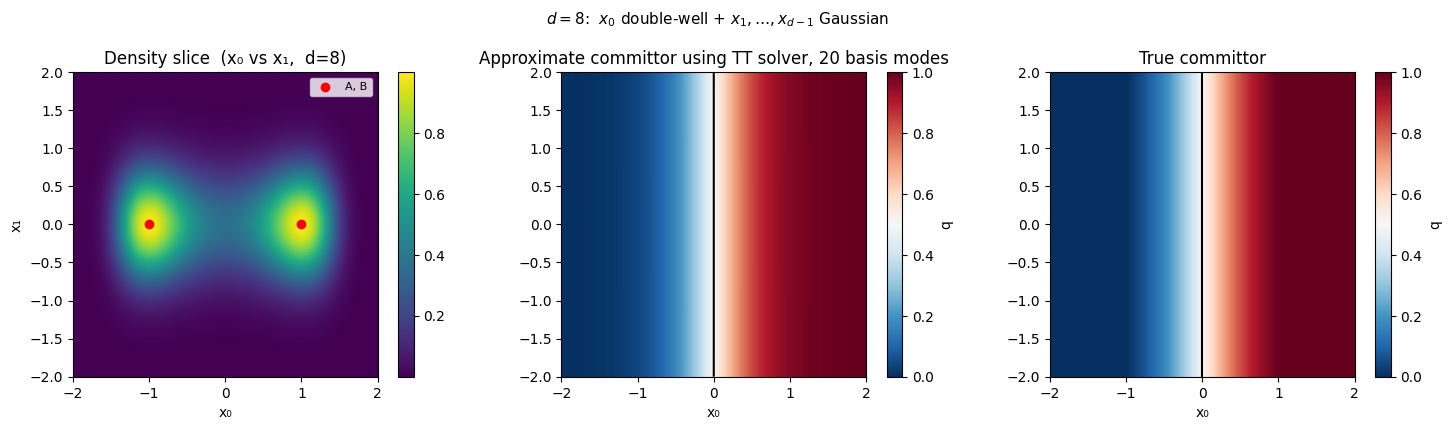

In [309]:
# ── figures ───────────────────────────────────────────────────────────────────
q_true_1d = committor_1d(xv)
ext = [-2, 2, -2, 2]
kw  = dict(origin='lower', extent=ext, aspect='equal')


yv = np.linspace(-2.0, 2.0, Ng)
X, Y = np.meshgrid(xv, yv)

# Density slice through dims 0 and 1 (others at 0 → contribute factor 1)
rho_slice = (
    np.exp(-beta_x * (xv**2 - 1.0)**2)[None, :] *
    np.exp(-beta_y * yv**2)[:, None]
)

q_true = np.tile(q_true_1d[None, :], (Ng, 1))  # independent of x₁
q_algo = eval_algo_on_slice(fix_y=0.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(rho_slice, cmap='viridis', **kw)
axes[0].scatter([-1, 1], [0, 0], c='red', zorder=5, label='A, B')
axes[0].set(title=f'Density slice  (x₀ vs x₁,  d={d})',
            xlabel='x₀', ylabel='x₁')
axes[0].legend(fontsize=8); plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(q_algo, cmap='RdBu_r', vmin=0, vmax=1, **kw)
axes[1].contour(X, Y, q_algo, levels=[0.5], colors='k', linewidths=1.5)
axes[1].set(title='Approximate committor using TT solver, 20 basis modes', xlabel='x₀')
plt.colorbar(im1, ax=axes[1], label='q')

im2 = axes[2].imshow(q_true, cmap='RdBu_r', vmin=0, vmax=1, **kw)
axes[2].contour(X, Y, q_true, levels=[0.5], colors='k', linewidths=1.5)
axes[2].set(title='True committor', xlabel='x₀')
plt.colorbar(im2, ax=axes[2], label='q')

plt.suptitle(
    rf'$d={d}$:  $x_0$ double-well + $x_1,\ldots,x_{{d-1}}$ Gaussian',
    fontsize=11, y=1.02,
)

plt.tight_layout()
plt.show()

In [307]:
np.max(abs(q_algo-q_true))

np.float64(0.04195337731747928)

# RECOVAR

## 2D

In [110]:
beta = 5.0
a, b = -1.5, 1.5
nquad = 500
quad_order = 400

d = 2
ns = [80] * d
intervals = [(a, b)] * d

N_gauss = 10
sigma_gauss = 0.28

xs_grid = np.linspace(a, b, 300)
X, Y = np.meshgrid(xs_grid, xs_grid)

In [111]:
def gaussian_1d(center, sigma):
    return lambda x, c=center, s=sigma: np.exp(-((x - c) / s) ** 2)

def centers(n_gauss):
    t = np.linspace(0.0, 2.0 * np.pi, n_gauss, endpoint=False)
    cx = np.sin(t)
    cy = np.sin(2.0 * t)
    return t, cx, cy

def density_grid(X, Y, cx, cy, sigma):
    dx = X[..., None] - cx[None, None, :]
    dy = Y[..., None] - cy[None, None, :]
    rho = np.exp(-(dx * dx + dy * dy) / sigma**2).sum(axis=-1)
    return rho / rho.max()

def build_tt_mixture_density(cx, cy, sigma, basis, nquad):
    components = [
        [gaussian_1d(x0, sigma), gaussian_1d(y0, sigma)]
        for x0, y0 in zip(cx, cy)
    ]
    return create_mixture_tt_density(
        components,
        basis,
        component_weights=[1.0 / len(cx)] * len(cx),
        nquad=nquad,
    )

def make_curve(t):
    return np.sin(t), np.sin(2.0 * t)


In [112]:
t_centers, cx_gauss, cy_gauss = centers(N_gauss)
t_curve = np.linspace(0.0, 2.0 * np.pi, 800)
liss_x, liss_y = make_curve(t_curve)

rho_lis = density_grid(X, Y, cx_gauss, cy_gauss, sigma_gauss)
V_lis = -np.log(rho_lis + 1e-10) / beta
V_lis -= V_lis.min()

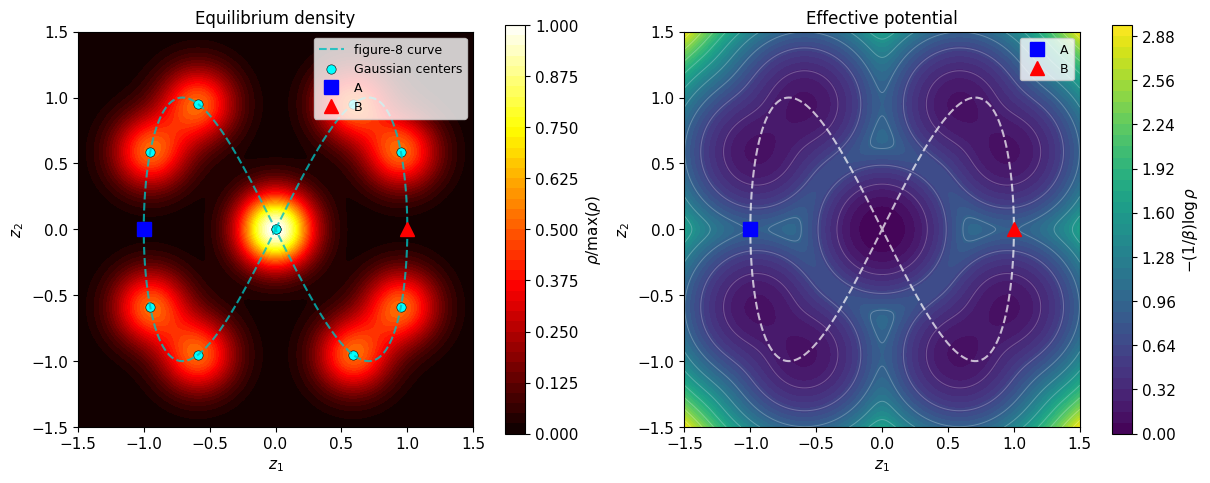

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

ax = axes[0]
cf = ax.contourf(X, Y, rho_lis, levels=40, cmap="hot")
fig.colorbar(cf, ax=ax, label=r"$\rho / \max(\rho)$", shrink=0.85)
ax.plot(liss_x, liss_y, "c--", lw=1.5, alpha=0.8, label="figure-8 curve")
ax.scatter(cx_gauss, cy_gauss, s=45, c="cyan", edgecolor="black", linewidth=0.4, label="Gaussian centers")
ax.plot(-1, 0, "bs", ms=10, label="A")
ax.plot(+1, 0, "r^", ms=10, label="B")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(a, b)
ax.set_ylim(a, b)
ax.set_title("Equilibrium density")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.legend(loc="upper right")

ax = axes[1]
cf = ax.contourf(X, Y, V_lis, levels=40, cmap="viridis")
fig.colorbar(cf, ax=ax, label=r"$-(1/\beta)\log \rho$", shrink=0.85)
ax.contour(X, Y, V_lis, levels=10, colors="white", alpha=0.25, linewidths=0.7)
ax.plot(liss_x, liss_y, "w--", lw=1.5, alpha=0.7)
ax.plot(-1, 0, "bs", ms=10, label="A")
ax.plot(+1, 0, "r^", ms=10, label="B")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(a, b)
ax.set_ylim(a, b)
ax.set_title("Effective potential")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.legend(loc="upper right")
#plt.savefig('/Users/matias/Downloads/committor_project/figs/toy_recovar_setup.png', dpi=300)

In [114]:
basis = make_basis(
    basis_kind="legendre",
    ns=ns,
    intervals=intervals,
)

density_spec = build_tt_mixture_density(
    cx_gauss,
    cy_gauss,
    sigma_gauss,
    basis,
    nquad=nquad,
)

print(f"TT density rank: {density_spec.J}")

wA_fns, wB_fns = make_gaussian_product_states(
    a_center=[-1.0, 0.0],
    b_center=[+1.0, 0.0],
    sigma=0.12,
)

TT density rank: 10


In [115]:
t0 = time.time()
result_lis = find_committor(
    ns=ns,
    intervals=intervals,
    wA_fns=wA_fns,
    wB_fns=wB_fns,
    rho=quad_order,
    method="tt",
    tt_rank=8,
    n_sweeps=25,
    density_spec=density_spec,
    verbose=True,
    nquad=nquad,
)
t_lis = time.time() - t0
print(f"Solved in {t_lis:.2f} s")

  [rho stage 1/4]  rho=0.4  (25 sweeps max)
  als_solve sweep   1/25 (L->R+R->L):  J = -0.03336456402
  als_solve sweep   2/25 (L->R+R->L):  J = -0.03484444812
  als_solve sweep   3/25 (L->R+R->L):  J = -0.03485042582
  als_solve sweep   4/25 (L->R+R->L):  J = -0.03485070761
  als_solve sweep   5/25 (L->R+R->L):  J = -0.03485072287
  als_solve sweep   6/25 (L->R+R->L):  J = -0.03485064862
  als_solve sweep   7/25 (L->R+R->L):  J = -0.03485036714
  als_solve sweep   8/25 (L->R+R->L):  J = -0.03485056347
  als_solve sweep   9/25 (L->R+R->L):  J = -0.03485089126
  als_solve sweep  10/25 (L->R+R->L):  J = -0.03485106296
  als_solve sweep  11/25 (L->R+R->L):  J = -0.03485121409
  als_solve sweep  12/25 (L->R+R->L):  J = -0.03485122328
  Converged after 12 sweeps (rel_change=8.88e-09 < tol=1.00e-08).
    -> converged in 12 sweep(s), J_final=-0.0348512
  [rho stage 2/4]  rho=4  (25 sweeps max)
  als_solve sweep   1/25 (L->R+R->L):  J = -0.360155954
  als_solve sweep   2/25 (L->R+R->L):  J = -

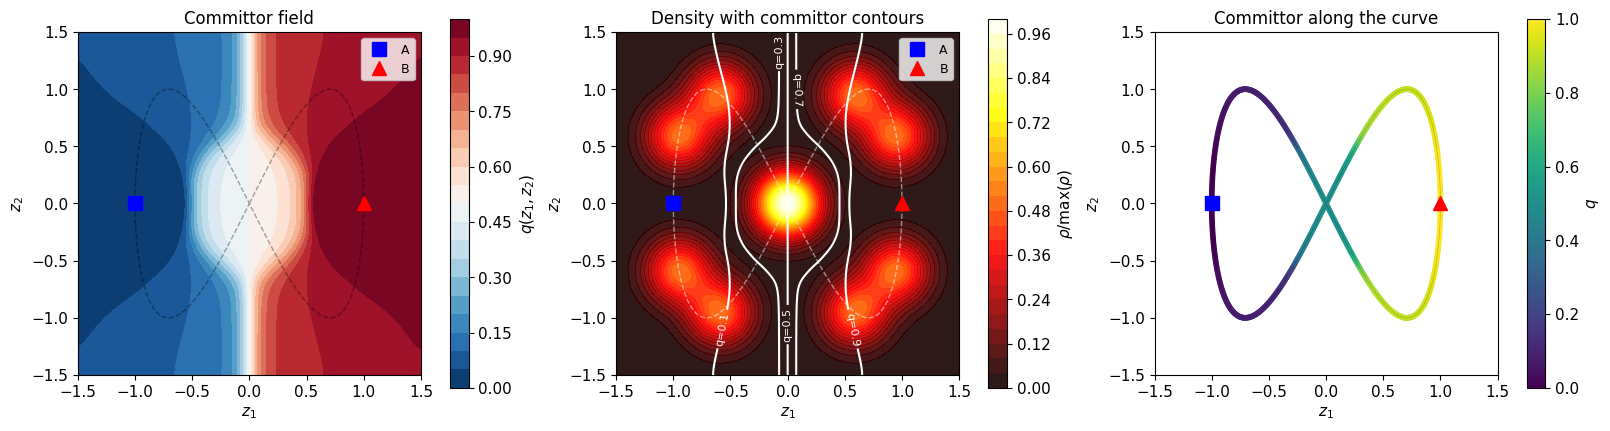

In [116]:
pts_grid = np.column_stack([X.ravel(), Y.ravel()])
Q = result_lis.q(pts_grid).reshape(X.shape)
Q = np.clip(Q, 0.0, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# Panel 1: q(x1, x2)
ax = axes[0]
cf = ax.contourf(X, Y, Q, levels=np.linspace(0, 1, 21), cmap="RdBu_r")
fig.colorbar(cf, ax=ax, label=r"$q(z_1, z_2)$", shrink=0.75)
ax.plot(liss_x, liss_y, "k--", lw=1.0, alpha=0.35)
ax.plot(-1, 0, "bs", ms=10, label="A")
ax.plot(+1, 0, "r^", ms=10, label="B")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(a, b)
ax.set_ylim(a, b)
ax.set_title("Committor field")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.legend(loc="upper right")


ax = axes[1]
cf = ax.contourf(X, Y, rho_lis, levels=30, cmap="hot", alpha=0.9)
fig.colorbar(cf, ax=ax, label=r"$\rho / \max(\rho)$", shrink=0.75)
levels = [0.1, 0.3, 0.5, 0.7, 0.9]
cs = ax.contour(X, Y, Q, levels=levels, colors="white", linewidths=1.5)
ax.clabel(cs, fmt=lambda v: f"q={v:.1f}", fontsize=8)
ax.plot(liss_x, liss_y, "w--", lw=1.0, alpha=0.5)
ax.plot(-1, 0, "bs", ms=10, label="A")
ax.plot(+1, 0, "r^", ms=10, label="B")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(a, b)
ax.set_ylim(a, b)
ax.set_title("Density with committor contours")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.legend(loc="upper right")

# Panel 3: committor sampled along the curve, colored by q
ax = axes[2]
t_eval = np.linspace(0.0, 2.0 * np.pi, 600)
curve_x, curve_y = make_curve(t_eval)
pts_curve = np.column_stack([curve_x, curve_y])
q_curve = np.clip(result_lis.q(pts_curve), 0.0, 1.0)

sc = ax.scatter(curve_x, curve_y, c=q_curve, s=10, cmap="viridis", vmin=0, vmax=1)
fig.colorbar(sc, ax=ax, label=r"$q$", shrink=0.75)
ax.plot(liss_x, liss_y, "k-", lw=0.5, alpha=0.2)
ax.plot(-1, 0, "bs", ms=10)
ax.plot(+1, 0, "r^", ms=10)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(a, b)
ax.set_ylim(a, b)
ax.set_title("Committor along the curve")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
#plt.savefig('/Users/matias/Downloads/committor_project/figs/recovar_2d.png', dpi=300)

## 4D

In [117]:
beta = 5.0
a, b = -1.5, 1.5
nquad = 500
quad_order = 400

d = 4
ns = [35] * d
intervals = [(a, b)] * d

N_gauss = 10
sigma_gauss = 0.28

xs_grid = np.linspace(a, b, 280)
X, Y = np.meshgrid(xs_grid, xs_grid)

In [118]:
def gaussian_1d(center, sigma):
    return lambda x, c=center, s=sigma: np.exp(-((x - c) / s) ** 2)

def centers_4d(n_gauss):
    """
    4D non-separable center curve.
    You can tweak the last two amplitudes if you want the slice x3=x4=0
    to cut through a denser region.
    """
    t = np.linspace(0.0, 2.0 * np.pi, n_gauss, endpoint=False)
    c1 = np.sin(t)
    c2 = np.sin(2.0 * t)
    c3 = 0.40 * np.sin(3.0 * t)
    c4 = 0.40 * np.cos(2.0 * t)
    return t, c1, c2, c3, c4

def curve_4d(t):
    return (
        np.sin(t),
        np.sin(2.0 * t),
        0.40 * np.sin(3.0 * t),
        0.40 * np.cos(2.0 * t),
    )

def density_slice_grid_4d(X, Y, c1, c2, c3, c4, sigma, z3=0.0, z4=0.0):
    """
    Evaluate a 4D Gaussian-mixture density on the slice (x3,x4)=(z3,z4).
    """
    dx1 = X[..., None] - c1[None, None, :]
    dx2 = Y[..., None] - c2[None, None, :]
    dx3 = z3 - c3[None, None, :]
    dx4 = z4 - c4[None, None, :]
    rho = np.exp(-(dx1 * dx1 + dx2 * dx2 + dx3 * dx3 + dx4 * dx4) / sigma**2).sum(axis=-1)
    return rho / rho.max()

def build_tt_mixture_density_4d(c1, c2, c3, c4, sigma, basis, nquad):
    components = [
        [
            gaussian_1d(x1, sigma),
            gaussian_1d(x2, sigma),
            gaussian_1d(x3, sigma),
            gaussian_1d(x4, sigma),
        ]
        for x1, x2, x3, x4 in zip(c1, c2, c3, c4)
    ]
    return create_mixture_tt_density(
        components,
        basis,
        component_weights=[1.0 / len(c1)] * len(c1),
        nquad=nquad,
    )

In [119]:
t_centers, c1_gauss, c2_gauss, c3_gauss, c4_gauss = centers_4d(N_gauss)

t_curve = np.linspace(0.0, 2.0 * np.pi, 800)
curve_x1, curve_x2, curve_x3, curve_x4 = curve_4d(t_curve)

rho_slice = density_slice_grid_4d(
    X, Y, c1_gauss, c2_gauss, c3_gauss, c4_gauss, sigma_gauss, z3=0.0, z4=0.0
)
V_slice = -np.log(rho_slice + 1e-10) / beta
V_slice -= V_slice.min()

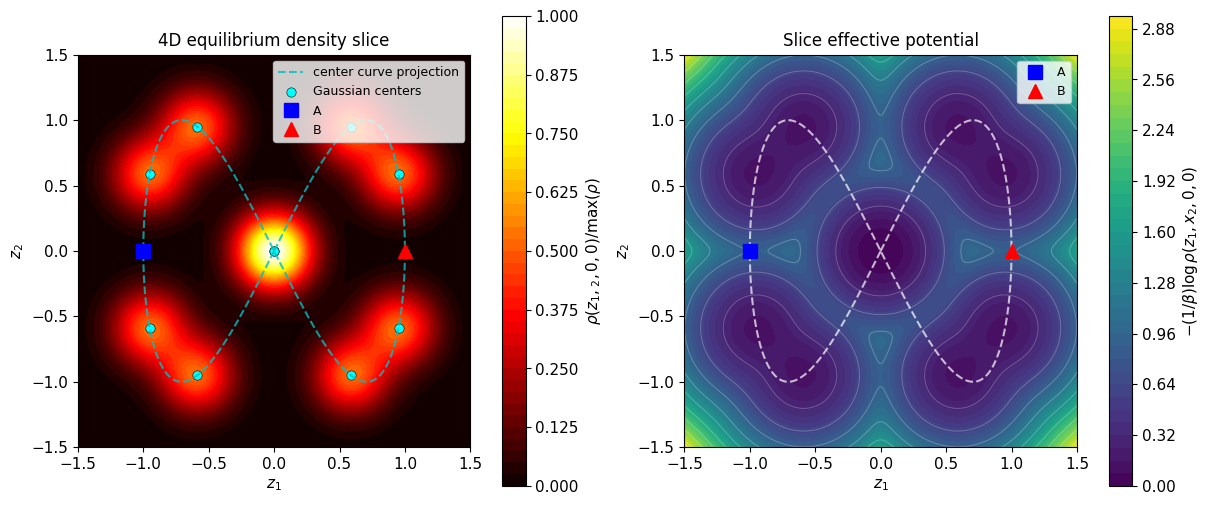

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

ax = axes[0]
cf = ax.contourf(X, Y, rho_slice, levels=40, cmap="hot")
fig.colorbar(cf, ax=ax, label=r"$\rho(z_1,_2,0,0) / \max(\rho)$")
ax.plot(curve_x1, curve_x2, "c--", lw=1.5, alpha=0.8, label="center curve projection")
ax.scatter(c1_gauss, c2_gauss, s=45, c="cyan", edgecolor="black", linewidth=0.4, label="Gaussian centers")
ax.plot(-1, 0, "bs", ms=10, label="A")
ax.plot(+1, 0, "r^", ms=10, label="B")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(a, b)
ax.set_ylim(a, b)
ax.set_title("4D equilibrium density slice")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.legend(loc="upper right")

ax = axes[1]
cf = ax.contourf(X, Y, V_slice, levels=40, cmap="viridis")
fig.colorbar(cf, ax=ax, label=r"$-(1/\beta)\log \rho(z_1,x_2,0,0)$")
ax.contour(X, Y, V_slice, levels=10, colors="white", alpha=0.25, linewidths=0.7)
ax.plot(curve_x1, curve_x2, "w--", lw=1.5, alpha=0.7)
ax.plot(-1, 0, "bs", ms=10, label="A")
ax.plot(+1, 0, "r^", ms=10, label="B")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(a, b)
ax.set_ylim(a, b)
ax.set_title("Slice effective potential")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.legend(loc="upper right")

In [121]:
basis = make_basis(
    basis_kind="legendre",
    ns=ns,
    intervals=intervals,
)

density_spec = build_tt_mixture_density_4d(
    c1_gauss,
    c2_gauss,
    c3_gauss,
    c4_gauss,
    sigma_gauss,
    basis,
    nquad=nquad,
)

print(f"TT density rank: {density_spec.J}")

wA_fns, wB_fns = make_gaussian_product_states(
    a_center=[-1.0, 0.0, 0.0, 0.0],
    b_center=[+1.0, 0.0, 0.0, 0.0],
    sigma=0.12,
)

TT density rank: 10


In [122]:
print("Solving committor...")
t0 = time.time()
result_4d = find_committor(
    ns=ns,
    intervals=intervals,
    wA_fns=wA_fns,
    wB_fns=wB_fns,
    rho=quad_order,
    method="tt",
    tt_rank=8,
    n_sweeps=50,
    density_spec=density_spec,
    verbose=True,
    nquad=nquad,
)
t_solve = time.time() - t0
print(f"Solved in {t_solve:.2f} s")

Solving committor...
  [rho stage 1/4]  rho=0.4  (50 sweeps max)
  als_solve sweep   1/50 (L->R+R->L):  J = -0.00325730508
  als_solve sweep   2/50 (L->R+R->L):  J = -0.003268583962
  als_solve sweep   3/50 (L->R+R->L):  J = -0.003271552787
  als_solve sweep   4/50 (L->R+R->L):  J = -0.003272025427
  als_solve sweep   5/50 (L->R+R->L):  J = -0.00327212981
  als_solve sweep   6/50 (L->R+R->L):  J = -0.00327217694
  als_solve sweep   7/50 (L->R+R->L):  J = -0.00327219694
  als_solve sweep   8/50 (L->R+R->L):  J = -0.003272209035
  als_solve sweep   9/50 (L->R+R->L):  J = -0.003272210715
  Converged after 9 sweeps (rel_change=1.67e-09 < tol=1.00e-08).
    -> converged in 9 sweep(s), J_final=-0.00327221
  [rho stage 2/4]  rho=4  (50 sweeps max)
  als_solve sweep   1/50 (L->R+R->L):  J = -0.03274141499
  als_solve sweep   2/50 (L->R+R->L):  J = -0.03274150863
  als_solve sweep   3/50 (L->R+R->L):  J = -0.03274156781
  als_solve sweep   4/50 (L->R+R->L):  J = -0.03274158983
  als_solve sweep

In [123]:
pts_slice = np.column_stack([
    X.ravel(),
    Y.ravel(),
    np.zeros(X.size),
    np.zeros(X.size),
])
Q_slice = result_4d.q(pts_slice).reshape(X.shape)
Q_slice = np.clip(Q_slice, 0.0, 1.0)

# Also evaluate along a 1D line: (x1, 0, 0, 0)
xs = np.linspace(a, b, 500)
pts_line = np.column_stack([
    xs,
    np.zeros_like(xs),
    np.zeros_like(xs),
    np.zeros_like(xs),
])
q_line = np.clip(result_4d.q(pts_line), 0.0, 1.0)

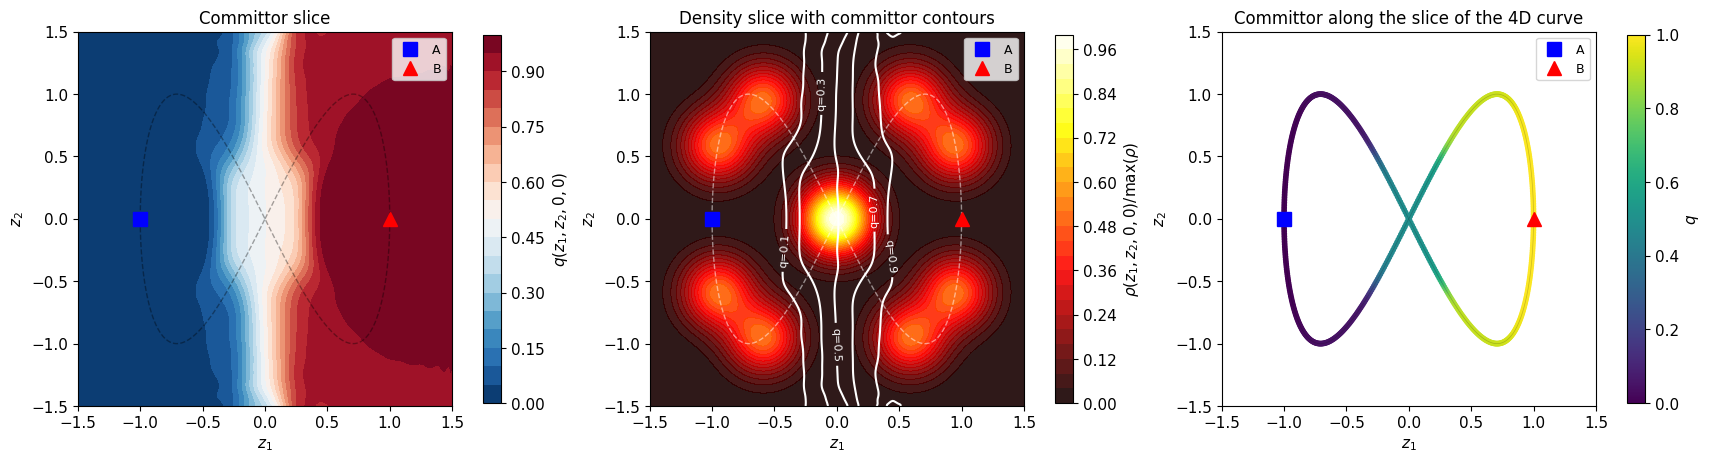

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)

# Panel 1: q(x1, x2, 0, 0)
ax = axes[0]
cf = ax.contourf(X, Y, Q_slice, levels=np.linspace(0, 1, 21), cmap="RdBu_r")
fig.colorbar(cf, ax=ax, label=r"$q(z_1,z_2,0,0)$", shrink=0.75)
ax.plot(curve_x1, curve_x2, "k--", lw=1.0, alpha=0.35)
ax.plot(-1, 0, "bs", ms=10, label="A")
ax.plot(+1, 0, "r^", ms=10, label="B")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(a, b)
ax.set_ylim(a, b)
ax.set_title("Committor slice")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.legend(loc="upper right")

# Panel 2: density slice with committor contours
ax = axes[1]
cf = ax.contourf(X, Y, rho_slice, levels=30, cmap="hot", alpha=0.9)
fig.colorbar(cf, ax=ax, label=r"$\rho(z_1,z_2,0,0) / \max(\rho)$", shrink=0.75)
levels = [0.1, 0.3, 0.5, 0.7, 0.9]
cs = ax.contour(X, Y, Q_slice, levels=levels, colors="white", linewidths=1.5)
ax.clabel(cs, fmt=lambda v: f"q={v:.1f}", fontsize=8)
ax.plot(curve_x1, curve_x2, "w--", lw=1.0, alpha=0.5)
ax.plot(-1, 0, "bs", ms=10, label="A")
ax.plot(+1, 0, "r^", ms=10, label="B")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(a, b)
ax.set_ylim(a, b)
ax.set_title("Density slice with committor contours")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.legend(loc="upper right")

# Panel 3: committor sampled along the 4D curve, colored by q
ax = axes[2]

t_eval = np.linspace(0.0, 2.0 * np.pi, 600)
curve_x1, curve_x2, curve_x3, curve_x4 = curve_4d(t_eval)

pts_curve = np.column_stack([curve_x1, curve_x2, curve_x3, curve_x4])
q_curve = np.clip(result_4d.q(pts_curve), 0.0, 1.0)

sc = ax.scatter(curve_x1, curve_x2, c=q_curve, s=10, cmap="viridis", vmin=0, vmax=1)
fig.colorbar(sc, ax=ax, label=r"$q$", shrink=0.75)

ax.plot(curve_x1, curve_x2, "k-", lw=0.5, alpha=0.2)
ax.plot(-1, 0, "bs", ms=10, label="A")
ax.plot(+1, 0, "r^", ms=10, label="B")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(a, b)
ax.set_ylim(a, b)
ax.set_title("Committor along the slice of the 4D curve")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.legend(loc="upper right")
plt.savefig('/Users/matias/Downloads/committor_project/figs/recovar_4d.png', dpi=300)